# BRICS Currency Unit — EGARCH Volatility Analysis

This notebook runs the full nine-step EGARCH volatility pipeline, importing from:
- `src/data_cleaning.py` — Step 1: data download & log returns
- `src/model.py` — Step 3: EGARCH(1,1) fitting
- `src/analysis.py` — Steps 2, 4–9: diagnostics, metrics, weights, simulation, plots, export

## Setup

In [27]:
!pip install arch yfinance statsmodels pandas numpy matplotlib scipy --quiet

In [28]:
import sys, os
# Add src/ to path so the three modules are importable from the notebook
sys.path.insert(0, os.path.join('..', 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1 — Data Download & Log Returns

Downloads daily FX closing prices for BRL, RUB, INR, CNY, ZAR and gold from Yahoo Finance.
Computes log returns scaled to %. Saves raw prices to `data/raw/` and returns to `data/processed/`.

In [29]:
from data_cleaning import run as fetch_data

prices, gold, returns = fetch_data(save=True)

print('\nPrices (first 3 rows):')
display(prices.head(3))
print('\nLog Returns (first 3 rows):')
display(returns.head(3))
print('\nGold (first 3 rows):')
display(gold.head(3).to_frame())


[1] Downloading FX data from Yahoo Finance...
    BRL: 2083 obs  (2017-01-02 → 2024-12-30)
    RUB: 2083 obs  (2017-01-02 → 2024-12-30)
    INR: 2083 obs  (2017-01-02 → 2024-12-30)
    CNY: 2082 obs  (2017-01-02 → 2024-12-30)
    ZAR: 2083 obs  (2017-01-02 → 2024-12-30)

    Prices shape: (2083, 5)

    Gold: 2010 obs  (2017-01-03 → 2024-12-30)
    Returns shape: (2080, 5)

    Raw data saved → data\raw/
      fx_prices.csv   (2083, 5)
      gold_prices.csv (2010,)

    Processed data saved → data\processed/
      fx_log_returns.csv  (2080, 5)

Prices (first 3 rows):


,BRL,RUB,INR,CNY,ZAR
Date,,,,,
2017-01-02,3.2532,61.231300,67.944801,6.9438,13.73569
2017-01-03,3.2840,61.228298,68.133904,6.9440,13.71040
2017-01-04,3.2635,60.923000,68.269798,6.9598,13.79659



Log Returns (first 3 rows):


,BRL,RUB,INR,CNY,ZAR
Date,,,,,
2017-01-03,0.942302,-0.004903,0.277931,0.002877,-0.184292
2017-01-04,-0.626194,-0.499869,0.199254,0.227276,0.626681
2017-01-05,-1.525289,-0.920128,-0.564504,-0.499823,-1.454287



Gold (first 3 rows):


,GC=F
Date,
2017-01-03,1160.400024
2017-01-04,1163.800049
2017-01-05,1179.699951


## Step 2 — Pre-fit Diagnostics

Runs the **Jarque-Bera** normality test and the **ARCH-LM** test on each return series.
A significant ARCH-LM p-value (< 0.05) confirms time-varying volatility and justifies EGARCH.

In [30]:
from analysis import run_preflight_diagnostics

pre_diag = run_preflight_diagnostics(returns)
display(pre_diag)


[2] Pre-fit diagnostics (ARCH-LM + Normality tests)...
          Mean (%)  Std (%)  Skewness  Ex.Kurtosis  JB p-value  ARCH-LM p ARCH effect
Currency                                                                             
BRL         0.0304   1.0378    0.2043       4.1855      0.0000     0.0000     YES ***
RUB         0.0257   9.0735    0.1431     781.4424      0.0000     0.0000     YES ***
INR         0.0107   0.3805    0.4498       6.0996      0.0000     0.0000     YES ***
CNY         0.0024   0.3303   -0.2496       7.3880      0.0000     0.0000     YES ***
ZAR         0.0146   1.1279   -0.0062      98.7286      0.0000     0.0000     YES ***


,Mean (%),Std (%),Skewness,Ex.Kurtosis,JB p-value,ARCH-LM p,ARCH effect
Currency,,,,,,,
BRL,0.030358,1.037772,0.204336,4.185460,0.0,2.205741e-26,YES ***
RUB,0.025717,9.073467,0.143142,781.442356,0.0,1.838460e-195,YES ***
INR,0.010731,0.380504,0.449750,6.099613,0.0,1.101337e-57,YES ***
CNY,0.002406,0.330269,-0.249564,7.388019,0.0,1.381395e-81,YES ***
ZAR,0.014558,1.127864,-0.006163,98.728618,0.0,2.333928e-182,YES ***


## Step 3 — Fit EGARCH(1,1)

Fits **EGARCH(1,1)** with Student-t errors (Nelson, 1991) to each currency:

$$\ln(\sigma^2_t) = \omega + \alpha[|z_{t-1}| - E|z_{t-1}|] + \gamma z_{t-1} + \beta \ln(\sigma^2_{t-1})$$

The log-variance formulation avoids positivity constraints and the $\gamma$ term captures leverage effects.

In [31]:
from model import fit_egarch

egarch_results = fit_egarch(returns)


[3] Fitting EGARCH(1,1) models...

  --- BRL ---
    ω (omega)  = 0.005190
    α (alpha)  = 0.094454   magnitude effect
    γ (gamma)  = nan   leverage effect
    β (beta)   = 0.988439   persistence
    AIC=5726.1   BIC=5754.3

  --- RUB ---
    ω (omega)  = 1.131548
    α (alpha)  = 1.441488   magnitude effect
    γ (gamma)  = nan   leverage effect
    β (beta)   = 0.820201   persistence
    AIC=5954.1   BIC=5982.3

  --- INR ---
    ω (omega)  = -0.005689
    α (alpha)  = 0.198212   magnitude effect
    γ (gamma)  = nan   leverage effect
    β (beta)   = 0.992337   persistence
    AIC=888.4   BIC=916.6

  --- CNY ---
    ω (omega)  = 0.032253
    α (alpha)  = 0.391374   magnitude effect
    γ (gamma)  = nan   leverage effect
    β (beta)   = 0.963998   persistence
    AIC=310.8   BIC=339.0

  --- ZAR ---
    ω (omega)  = -0.025535
    α (alpha)  = 0.251053   magnitude effect
    γ (gamma)  = nan   leverage effect
    β (beta)   = 0.732313   persistence
    AIC=5639.1   BIC=5667.3


## Step 4 — Post-fit Diagnostics

Checks the standardised residuals $z_t = \varepsilon_t / \sigma_t$ for:
- Mean ≈ 0, Std ≈ 1
- No serial correlation in $z_t$ or $z_t^2$ (Ljung-Box)
- Persistence $(\alpha + \beta)$ and shock half-life

In [32]:
from analysis import post_fit_diagnostics

post_diag = post_fit_diagnostics(egarch_results)
display(post_diag)


[4] Post-fit diagnostics on standardised residuals...
          StdResid Mean  StdResid Std  LB(10) p  (z_t)  LB(10) p  (z²_t)  Leverage γ  Persistence (α+β)  Half-life (days)
Currency                                                                                                                 
BRL              0.0152        1.0019           0.0001            0.0003         NaN             1.0829           59.6101
RUB             -0.0311        2.7503           1.0000            1.0000         NaN             2.2617            3.4971
INR              0.0282        1.0282           0.0000            0.1949         NaN             1.1905           90.1009
CNY             -0.0148        0.8061           0.0005            0.0247         NaN             1.3554           18.9043
ZAR              0.0155        1.0659           0.1074            1.0000         NaN             0.9834            2.2249


,StdResid Mean,StdResid Std,LB(10) p (z_t),LB(10) p (z²_t),Leverage γ,Persistence (α+β),Half-life (days)
Currency,,,,,,,
BRL,0.015212,1.001891,0.000112,0.000295,NaN,1.082894,59.610114
RUB,-0.031148,2.750251,1.000000,1.000000,NaN,2.261689,3.497116
INR,0.028227,1.028226,0.000036,0.194902,NaN,1.190549,90.100934
CNY,-0.014820,0.806130,0.000452,0.024662,NaN,1.355372,18.904307
ZAR,0.015519,1.065899,0.107447,0.999998,NaN,0.983366,2.224851


## Step 5 — Volatility Metrics & Stability Ranking

Extracts three metrics per currency and ranks by **mean conditional variance** (ascending = most stable):
1. Mean conditional variance (primary ranking metric)
2. Unconditional (long-run) variance: $\sigma^2_{LR} = \exp(\omega / (1-\beta))$
3. Persistence $(\alpha + \beta)$

In [33]:
from analysis import compute_volatility_metrics

metrics = compute_volatility_metrics(egarch_results)
display(metrics)


[5] Computing volatility metrics and stability ranking...

  Volatility Metrics — sorted most stable → least stable:
          Mean Cond. Var (daily %²)  Mean Cond. Vol (ann. %)  Unconditional Var  Persistence (α+β)  Half-life (days)  Stability Rank
Currency                                                                                                                            
INR                          0.1578                   6.3058             0.4760             1.1905           90.1009               1
CNY                          0.1887                   6.8965             2.4495             1.3554           18.9043               2
ZAR                          0.9888                  15.7854             0.9090             0.9834            2.2249               3
BRL                          1.0697                  16.4183             1.5667             1.0829           59.6101               4
RUB                    2368641.2968               24431.4880           541.0003     

,Mean Cond. Var (daily %²),Mean Cond. Vol (ann. %),Unconditional Var,Persistence (α+β),Half-life (days),Stability Rank
Currency,,,,,,
INR,1.577886e-01,6.305770,0.475977,1.190549,90.100934,1
CNY,1.887355e-01,6.896474,2.449484,1.355372,18.904307,2
ZAR,9.888074e-01,15.785420,0.909017,0.983366,2.224851,3
BRL,1.069685e+00,16.418299,1.566706,1.082894,59.610114,4
RUB,2.368641e+06,24431.488018,541.000254,2.261689,3.497116,5


## Step 6 — Weight Constraints

Derives the EGARCH ordering constraint and inverse-variance seed weights for the basket optimiser.

In [34]:
from analysis import derive_weight_constraints

constraints = derive_weight_constraints(metrics)


[6] Deriving weight constraints...

  Inverse-variance weights (seed / reference solution):
    w_INR = 0.4666   (46.7%)
    w_CNY = 0.3901   (39.0%)
    w_ZAR = 0.0745   (7.4%)
    w_BRL = 0.0688   (6.9%)
    w_RUB = 0.0000   (0.0%)
    Sum    = 1.000000  ✓

  Ordering constraint (from EGARCH stability rank):
    w_INR >= w_CNY >= w_ZAR >= w_BRL >= w_RUB


## Step 7 — BRICS UNIT Simulation

Simulates the UNIT index:

$$\text{UNIT}_t = 0.6 \times \sum_i w_i \frac{\text{FX}_{i,t}}{\text{FX}_{i,0}} + 0.4 \times \frac{\text{Gold}_t}{\text{Gold}_0}$$

All components normalised to 1.0 at the start date.

In [35]:
from analysis import simulate_unit_value

unit_df = simulate_unit_value(prices, gold, weights=constraints['iv_weights'])
display(unit_df.tail(3))


[7] Simulating BRICS UNIT value...
    UNIT annualised vol  : 13.6214%
    UNIT total return    : 63.39%


,UNIT,Basket,Gold
Date,,,
2024-12-26,1.645199,1.225969,2.274043
2024-12-27,1.637180,1.225013,2.255429
2024-12-30,1.633862,1.225861,2.245864


## Step 8 — Plots

Generates and saves four sets of figures to `results/figures/`.

    Saved: results\figures\brics_conditional_vol.png


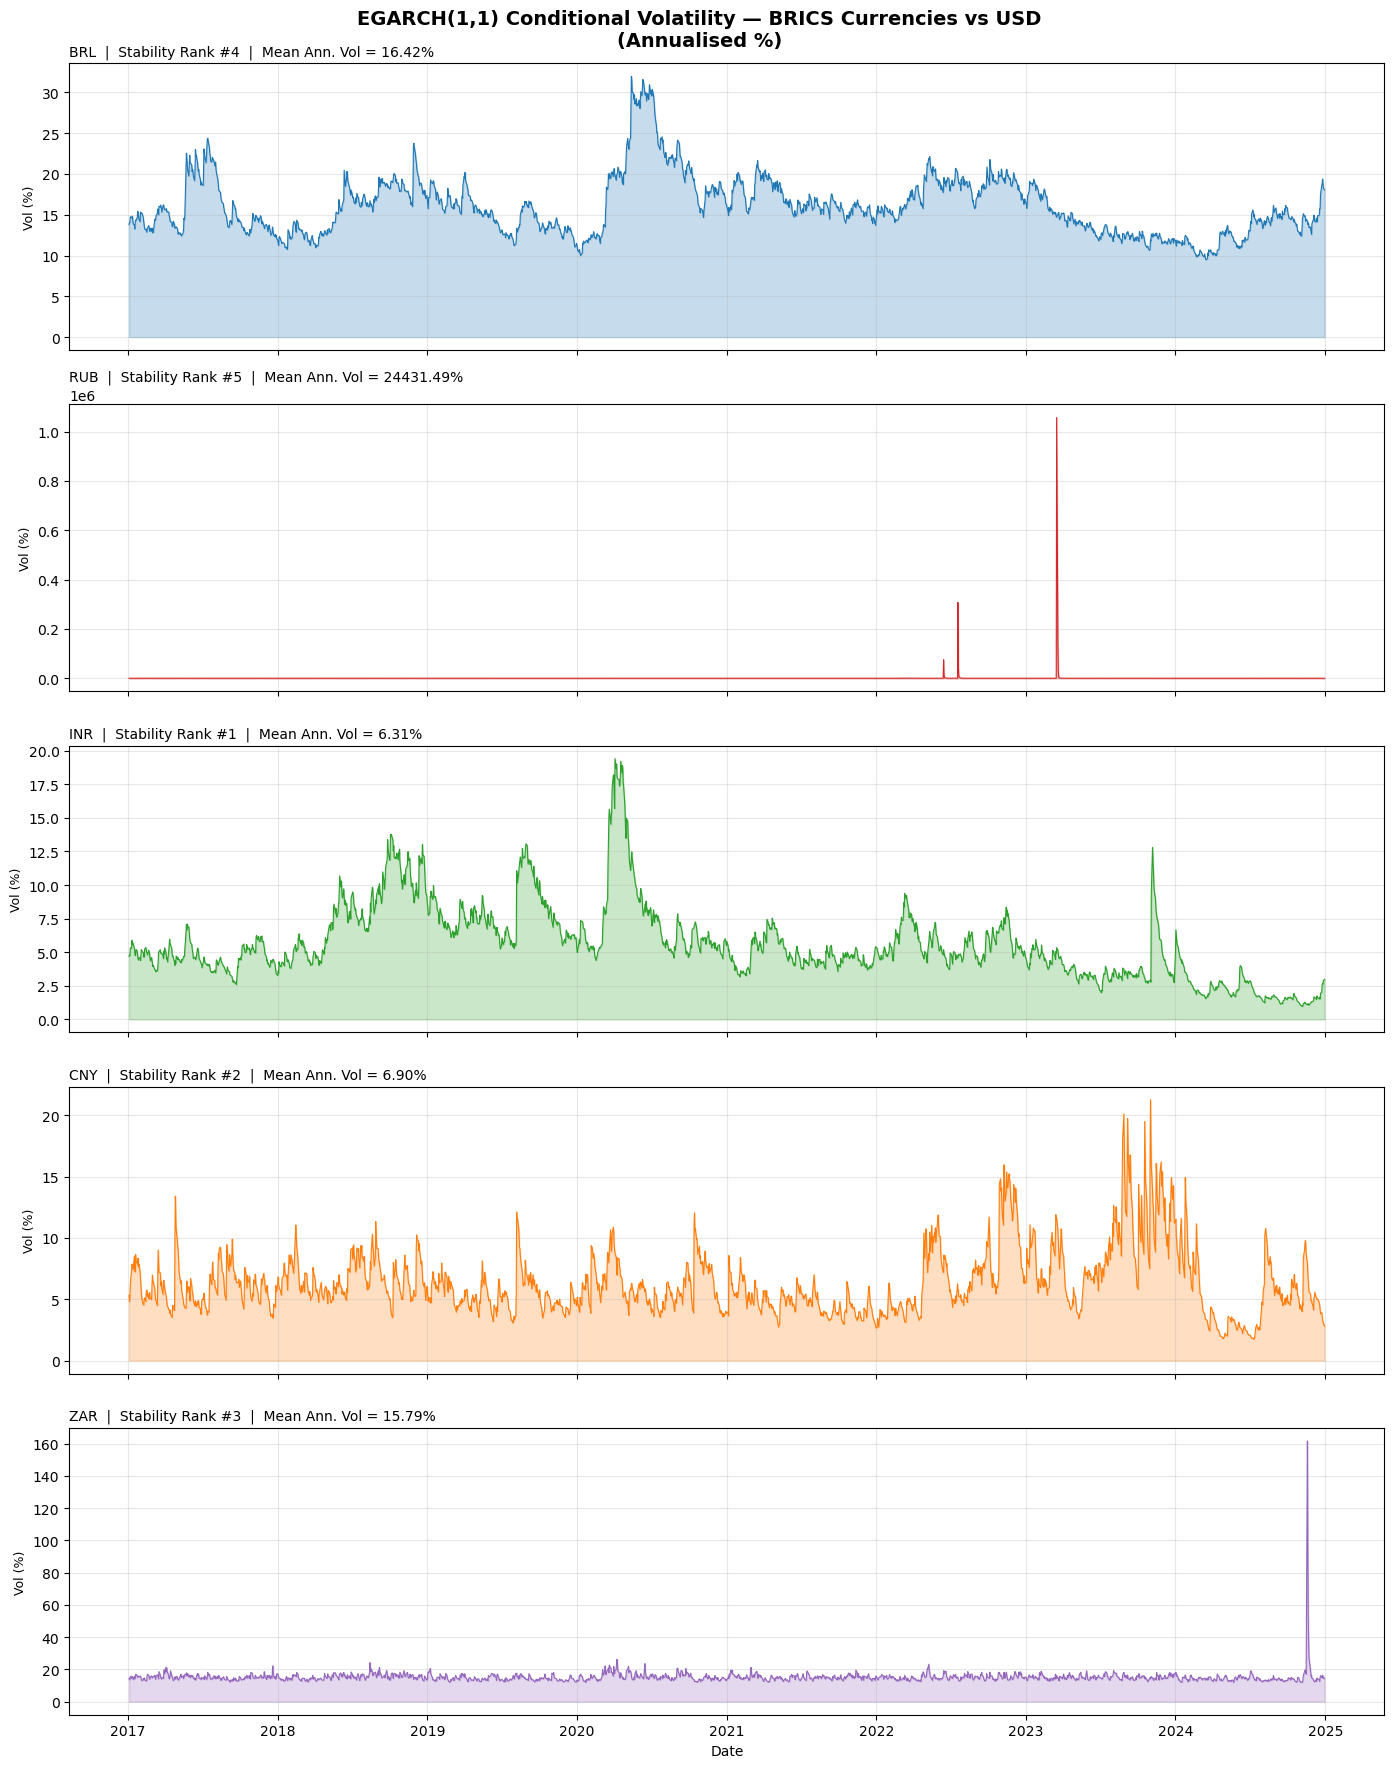

    Saved: results\figures\brics_stability_ranking.png


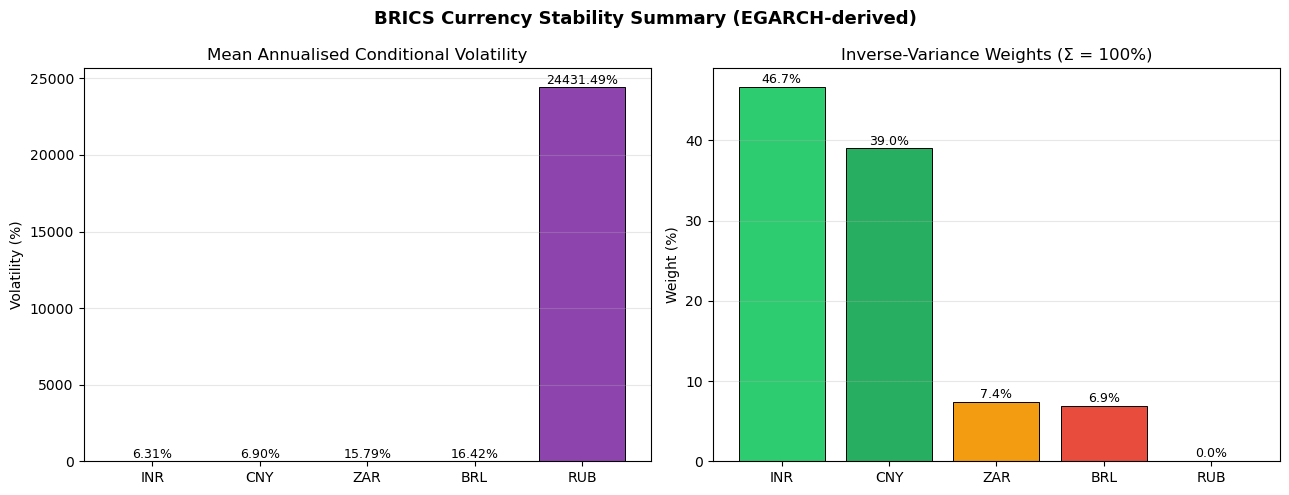

    Saved: results\figures\brics_unit_index.png


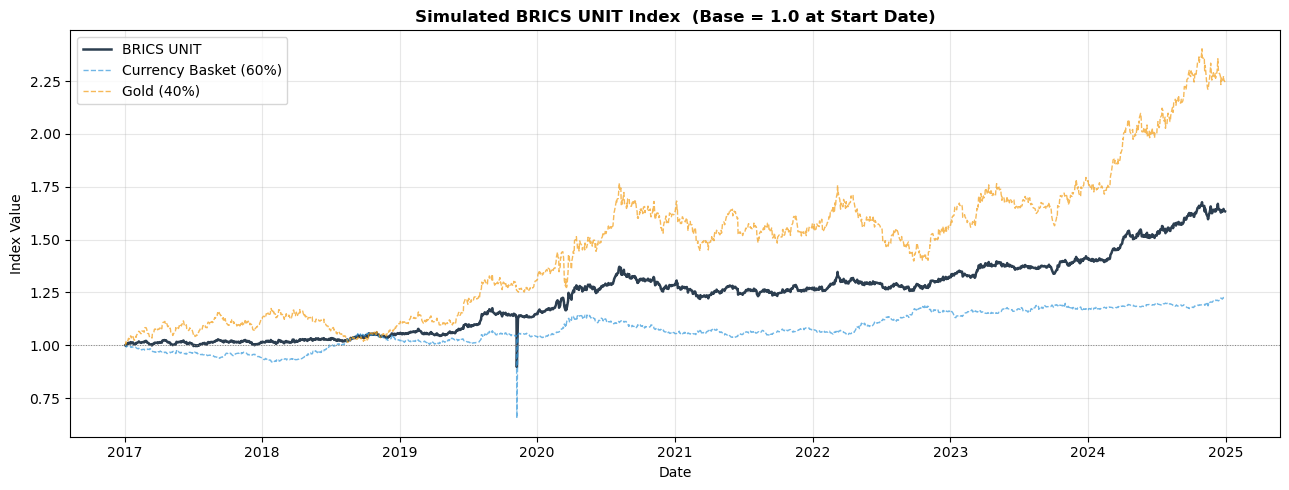

    Saved: results\figures\brics_diag_BRL.png


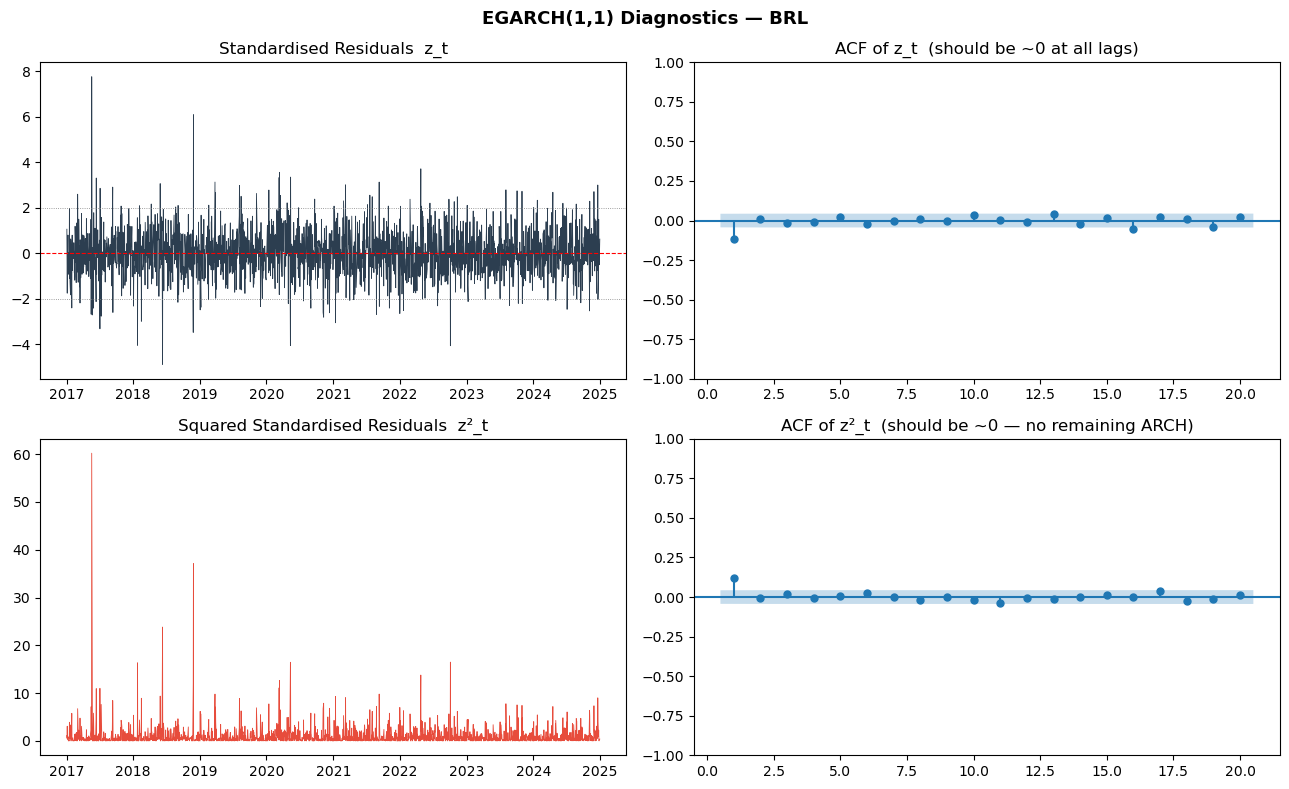

    Saved: results\figures\brics_diag_RUB.png


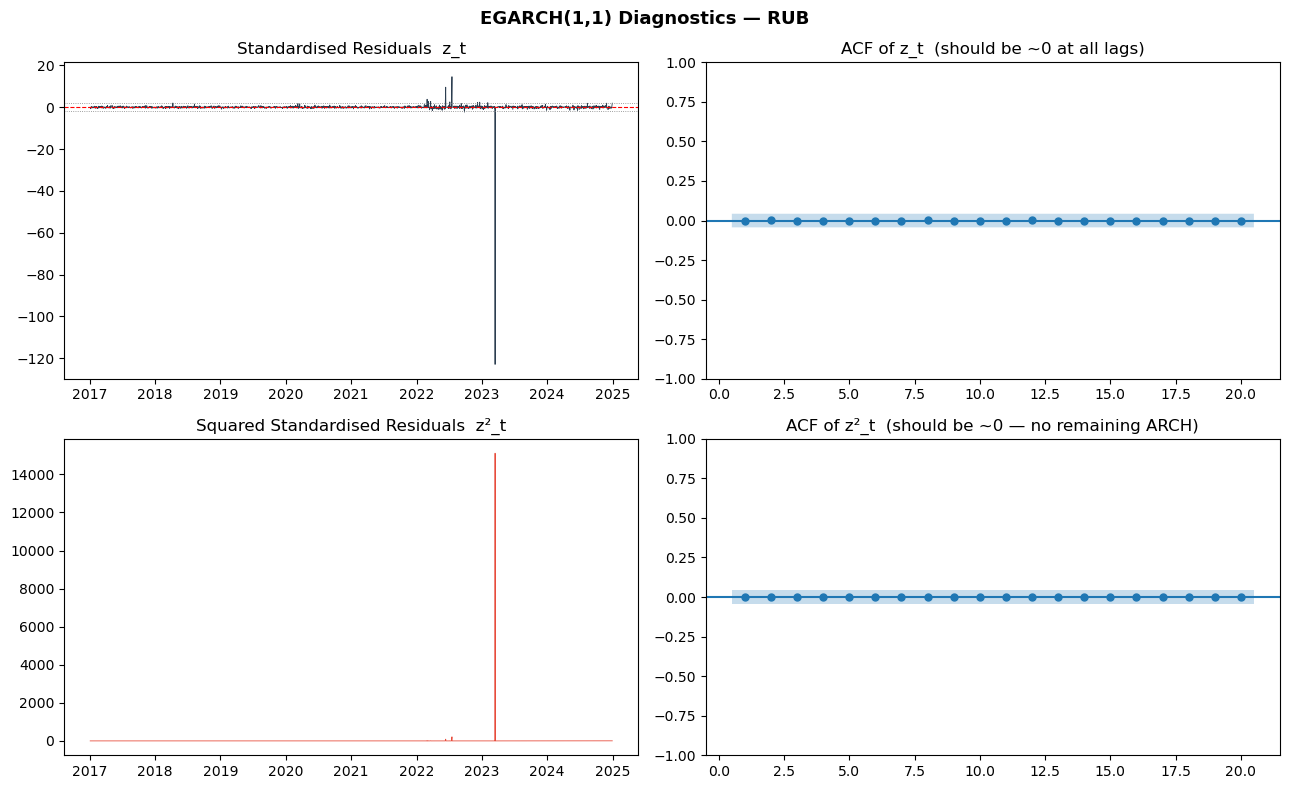

    Saved: results\figures\brics_diag_INR.png


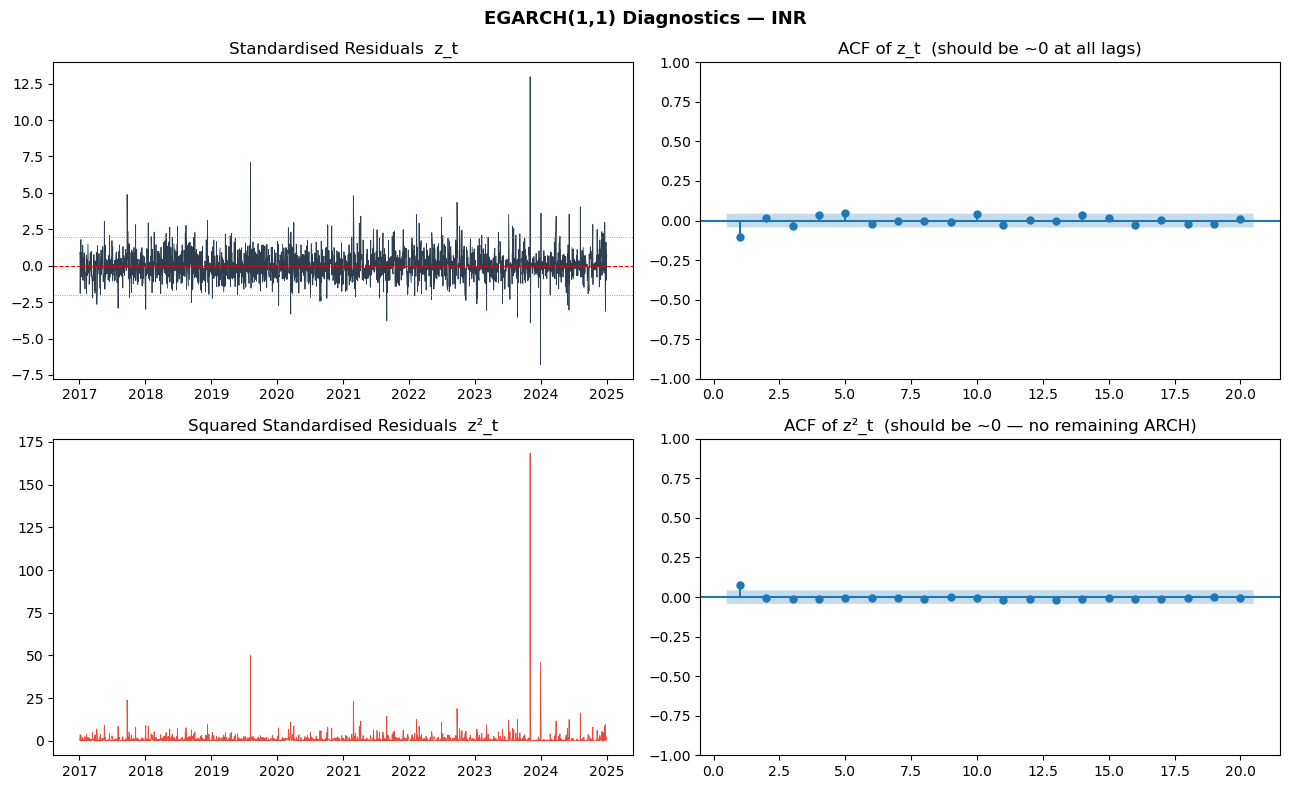

    Saved: results\figures\brics_diag_CNY.png


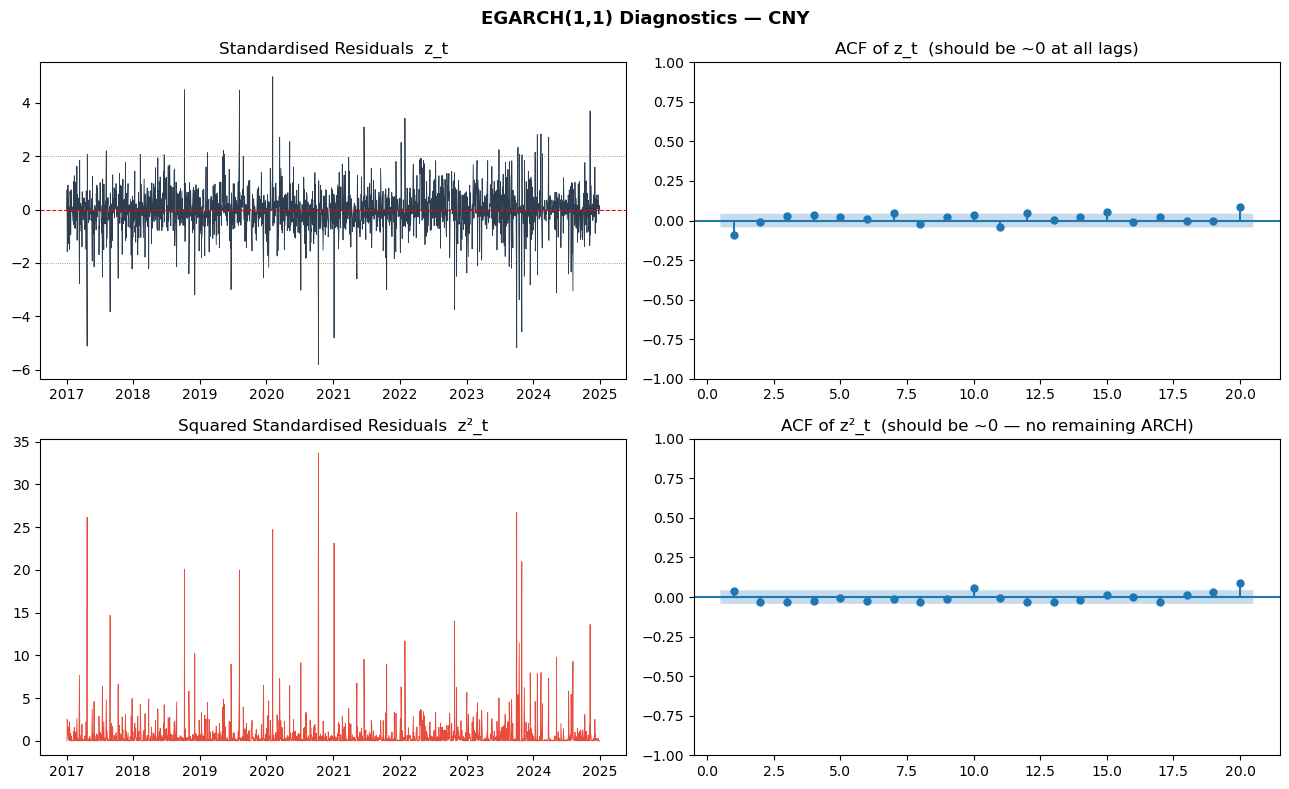

    Saved: results\figures\brics_diag_ZAR.png


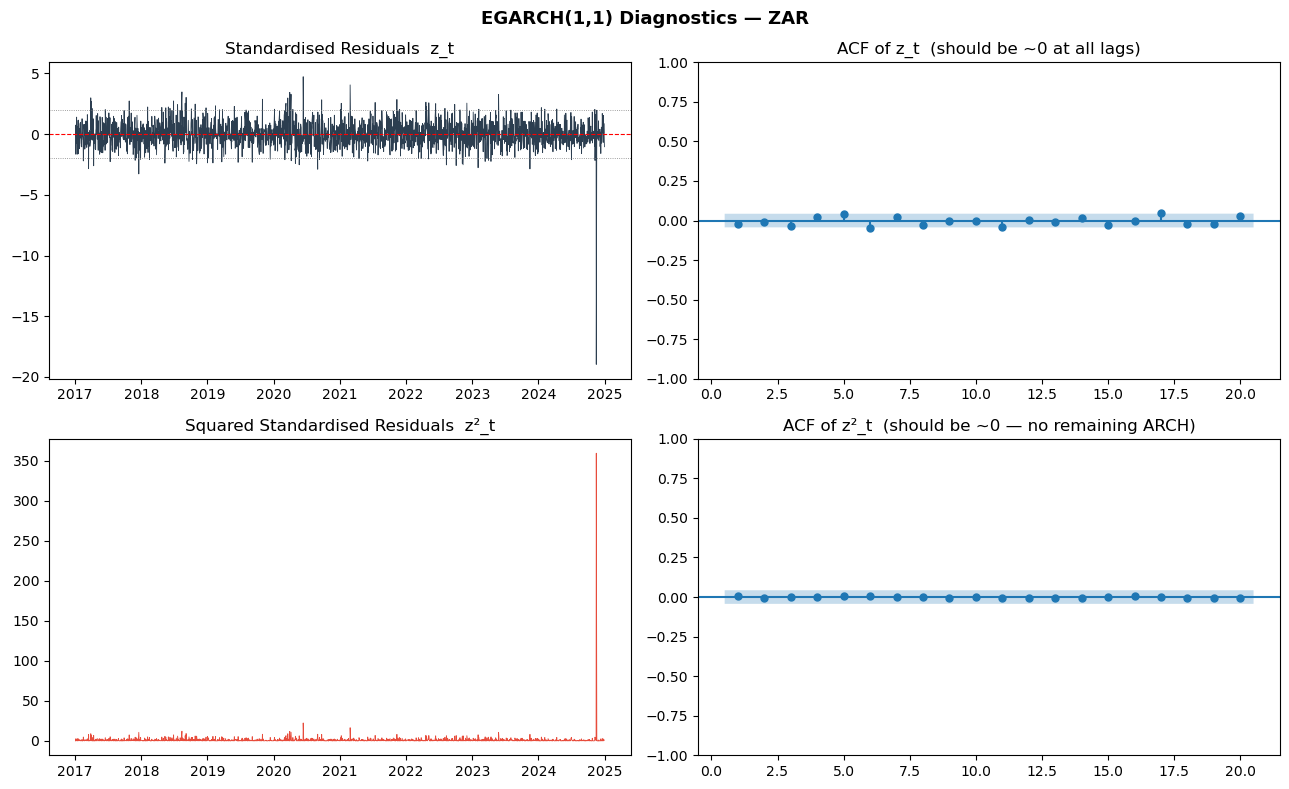

In [36]:
from analysis import (
    plot_conditional_volatility,
    plot_stability_ranking,
    plot_unit_value,
    plot_egarch_diagnostics,
    FIGURES_DIR,
)
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

plot_conditional_volatility(
    egarch_results, metrics,
    save_path=os.path.join(FIGURES_DIR, 'brics_conditional_vol.png'),
)
plot_stability_ranking(
    metrics, constraints,
    save_path=os.path.join(FIGURES_DIR, 'brics_stability_ranking.png'),
)
plot_unit_value(
    unit_df,
    save_path=os.path.join(FIGURES_DIR, 'brics_unit_index.png'),
)
plot_egarch_diagnostics(
    egarch_results,
    save_prefix=os.path.join(FIGURES_DIR, 'brics_diag'),
)

## Step 9 — Export Results

Saves all tables (metrics, weights, diagnostics) to `results/tables/` as CSVs.

In [37]:
from analysis import export_results

export_results(metrics, constraints, pre_diag, post_diag)


[9] Results saved to 'results\tables/'
    egarch_volatility_metrics.csv
    prefit_diagnostics.csv
    postfit_diagnostics.csv
    egarch_weights.csv


## Final Summary — Weight Constraints for Optimiser

In [38]:
ordered = constraints['ordered_currencies']
iv_w    = constraints['iv_weights']

print('=' * 65)
print('  FINAL WEIGHT CONSTRAINTS FOR OPTIMISER')
print('=' * 65)
print('\n  UNIT = 0.6 × [Σ w_i · FX_i] + 0.4 × Gold')
print('\n  EGARCH-derived ordering constraint:')
print('    ' + ' >= '.join([f'w_{c}' for c in ordered]))
print('\n  Inverse-variance seed weights (one valid solution):')
for c in ordered:
    w = iv_w[c]
    print(f'    w_{c} = {w:.4f}  ({w*100:.1f}%)')
print(f'\n  Sum = {iv_w.sum():.6f}  ✓')
print('\n  Feed the ordering constraint + Σw=1 + w_i≥0 into your')
print('  delta-UNIT=0 linear system to filter the infinite set.')

  FINAL WEIGHT CONSTRAINTS FOR OPTIMISER

  UNIT = 0.6 × [Σ w_i · FX_i] + 0.4 × Gold

  EGARCH-derived ordering constraint:
    w_INR >= w_CNY >= w_ZAR >= w_BRL >= w_RUB

  Inverse-variance seed weights (one valid solution):
    w_INR = 0.4666  (46.7%)
    w_CNY = 0.3901  (39.0%)
    w_ZAR = 0.0745  (7.4%)
    w_BRL = 0.0688  (6.9%)
    w_RUB = 0.0000  (0.0%)

  Sum = 1.000000  ✓

  Feed the ordering constraint + Σw=1 + w_i≥0 into your
  delta-UNIT=0 linear system to filter the infinite set.
